In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers_df = pd.read_csv("data/raw/customers.csv")
backup_jobs_df = pd.read_csv("data/raw/backup_jobs.csv")
storage_usage_df = pd.read_csv("data/raw/storage_usage.csv")
security_alerts_df = pd.read_csv("data/raw/security_alerts.csv")
recovery_logs_df = pd.read_csv("data/raw/recovery_logs.csv")

In [3]:
customers_df.head()

,customer_id,company_name,industry,cloud_provider,company_size,region,subscription_plan
0,1,Thomas-Scott,Finance,AWS,Large,Europe,Standard
1,2,Jones-Hart,Healthcare,Google Cloud,Small,North America,Enterprise
2,3,Thompson-Chavez,Technology,AWS,Small,North America,Standard
3,4,"Richards, Moore and Mcguire",Healthcare,Google Cloud,Small,Europe,Enterprise
4,5,Edwards-Rowe,Manufacturing,Azure,Medium,South America,Enterprise


In [4]:
backup_jobs_df.head()

,job_id,customer_id,backup_date,backup_size_gb,backup_status,backup_duration_min,recovery_time_min,storage_cost_usd,cloud_provider,region
0,1,1,2025-01-01,2480.93,Success,24.81,29.772,49.62,AWS,Europe
1,2,1,2025-01-02,2277.32,Success,22.77,27.324,45.55,AWS,Europe
2,3,1,2025-01-03,3518.33,Success,35.18,42.216,70.37,AWS,Europe
3,4,1,2025-01-04,1689.52,Success,16.90,20.280,33.79,AWS,Europe
4,5,1,2025-01-05,4297.44,Success,42.97,51.564,85.95,AWS,Europe


In [5]:
backup_jobs_df.shape

(50000, 10)

In [6]:
backup_jobs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   job_id               50000 non-null  int64  
 1   customer_id          50000 non-null  int64  
 2   backup_date          50000 non-null  str    
 3   backup_size_gb       50000 non-null  float64
 4   backup_status        50000 non-null  str    
 5   backup_duration_min  50000 non-null  float64
 6   recovery_time_min    50000 non-null  float64
 7   storage_cost_usd     50000 non-null  float64
 8   cloud_provider       50000 non-null  str    
 9   region               50000 non-null  str    
dtypes: float64(4), int64(2), str(4)
memory usage: 3.8 MB


In [7]:
backup_jobs_df.describe()

,job_id,customer_id,backup_size_gb,backup_duration_min,recovery_time_min,storage_cost_usd
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,25000.500000,500.500000,3328.801468,33.288019,35.887010,66.576065
std,14433.901067,288.677877,3499.119675,34.991190,41.086298,69.982396
min,1.000000,1.000000,50.020000,0.500000,0.000000,1.000000
25%,12500.750000,250.750000,412.177500,4.120000,3.096000,8.240000
50%,25000.500000,500.500000,1680.225000,16.800000,15.900000,33.600000
75%,37500.250000,750.250000,5374.967500,53.750000,56.952000,107.500000
max,50000.000000,1000.000000,11999.510000,120.000000,144.000000,239.990000


In [8]:
#Which Cloud Provider is the Most Reliable?
cloud_success = (
    backup_jobs_df
    .groupby("cloud_provider")["backup_status"]
    .value_counts()
    .unstack()
)

cloud_success

backup_status,Failed,Success
cloud_provider,,
AWS,1016,16034
Azure,1061,15489
Google Cloud,1110,15290


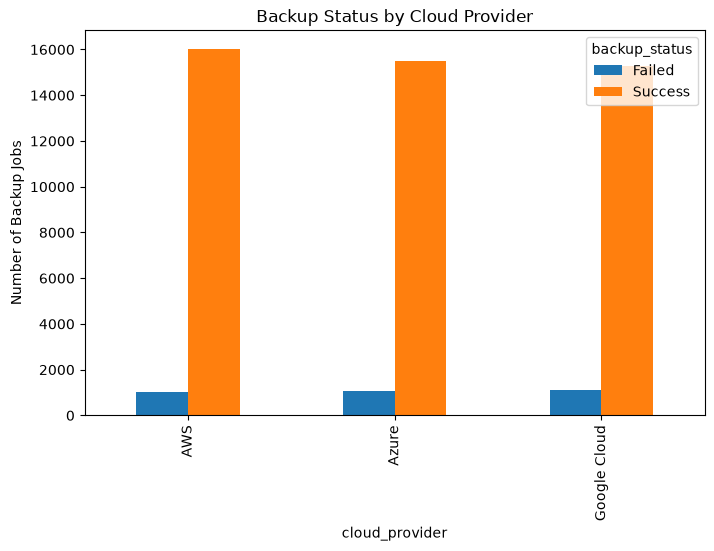

In [9]:
cloud_success.plot(kind="bar", figsize=(8,5))

plt.title("Backup Status by Cloud Provider")
plt.ylabel("Number of Backup Jobs")
plt.show()

In [10]:
#Which Industry Consumes the Most Storage?
merged_df = backup_jobs_df.merge(
    customers_df,
    on="customer_id"
)

merged_df.head()

,job_id,customer_id,backup_date,backup_size_gb,backup_status,backup_duration_min,recovery_time_min,storage_cost_usd,cloud_provider_x,region_x,company_name,industry,cloud_provider_y,company_size,region_y,subscription_plan
0,1,1,2025-01-01,2480.93,Success,24.81,29.772,49.62,AWS,Europe,Thomas-Scott,Finance,AWS,Large,Europe,Standard
1,2,1,2025-01-02,2277.32,Success,22.77,27.324,45.55,AWS,Europe,Thomas-Scott,Finance,AWS,Large,Europe,Standard
2,3,1,2025-01-03,3518.33,Success,35.18,42.216,70.37,AWS,Europe,Thomas-Scott,Finance,AWS,Large,Europe,Standard
3,4,1,2025-01-04,1689.52,Success,16.90,20.280,33.79,AWS,Europe,Thomas-Scott,Finance,AWS,Large,Europe,Standard
4,5,1,2025-01-05,4297.44,Success,42.97,51.564,85.95,AWS,Europe,Thomas-Scott,Finance,AWS,Large,Europe,Standard


In [11]:
industry_storage = (
    merged_df
    .groupby("industry")["storage_cost_usd"]
    .sum()
    .sort_values(ascending=False)
)

industry_storage

industry
Finance          711244.65
Retail           702039.80
Technology       675322.80
Manufacturing    647779.60
Healthcare       592416.41
Name: storage_cost_usd, dtype: float64

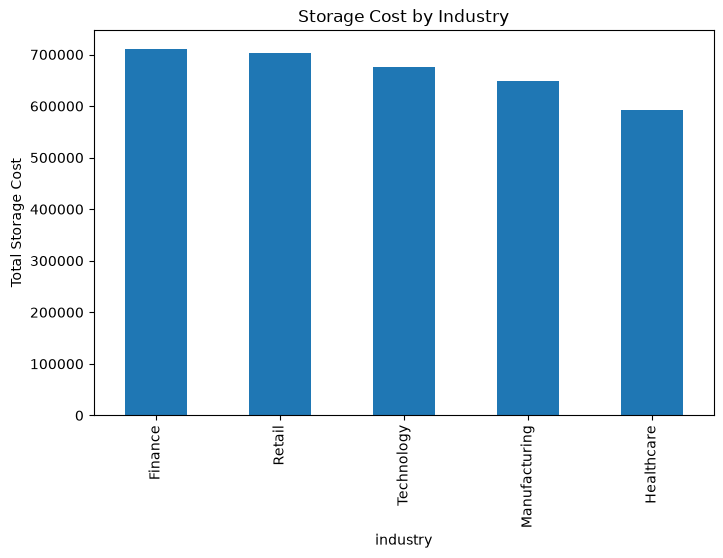

In [12]:
industry_storage.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Storage Cost by Industry")

plt.ylabel("Total Storage Cost")

plt.show()

In [13]:
#Failure Rate by Company Size

In [14]:
failure_rate = (
    merged_df
    .groupby("company_size")["backup_status"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("Percentage")
    .reset_index()
)

failure_rate

,company_size,backup_status,Percentage
0,Enterprise,Success,88.037736
1,Enterprise,Failed,11.962264
2,Large,Success,92.830645
3,Large,Failed,7.169355
4,Medium,Success,96.076923
5,Medium,Failed,3.923077
6,Small,Success,98.211454
7,Small,Failed,1.788546


In [15]:
#Filter only failed backups
failed = failure_rate[
    failure_rate["backup_status"]=="Failed"
]

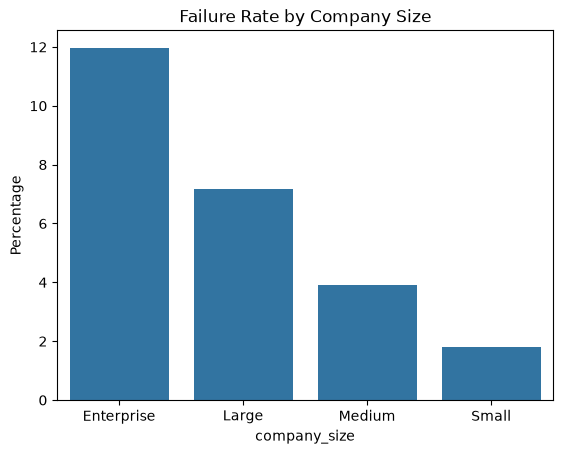

In [16]:
sns.barplot(
    data=failed,
    x="company_size",
    y="Percentage"
)

plt.title("Failure Rate by Company Size")

plt.show()

In [17]:
#Which Customers Have the Most Backup Failures?
customer_failures = (
    backup_jobs_df[backup_jobs_df["backup_status"] == "Failed"]
    .groupby("customer_id")
    .size()
    .reset_index(name="failure_count")
)

In [18]:
#Get the Top 10 customers
top_failures = (
    customer_failures
    .sort_values("failure_count", ascending=False)
    .head(10)
)

top_failures

,customer_id,failure_count
820,953,12
620,718,12
626,725,12
177,210,12
362,421,12
737,856,11
676,783,11
532,611,11
464,531,11
215,251,11


In [19]:
top_failures = top_failures.merge(
    customers_df[["customer_id", "company_name"]],
    on="customer_id"
)

top_failures

,customer_id,failure_count,company_name
0,953,12,Lopez-Johnson
1,718,12,Strickland-Mack
2,725,12,Torres PLC
3,210,12,Burnett LLC
4,421,12,Sims LLC
5,856,11,Buchanan-Acevedo
6,783,11,Ortiz-Golden
7,611,11,"Donaldson, Morrison and Frye"
8,531,11,Stephens LLC
9,251,11,"Brown, Dodson and Martin"


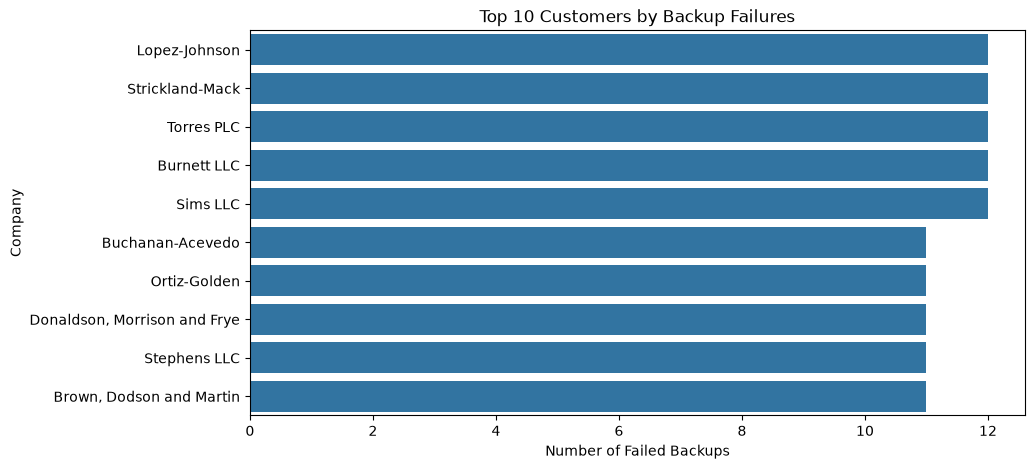

In [20]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top_failures,
    x="failure_count",
    y="company_name"
)

plt.title("Top 10 Customers by Backup Failures")

plt.xlabel("Number of Failed Backups")
plt.ylabel("Company")

plt.show()

In [21]:
#Monthly Backup Trend
backup_jobs_df["backup_date"] = pd.to_datetime(
    backup_jobs_df["backup_date"]
)

In [22]:
#Create Month column
backup_jobs_df["month"] = (
    backup_jobs_df["backup_date"]
    .dt.month_name()
)

In [23]:
#Count backups
monthly_jobs = (
    backup_jobs_df
    .groupby("month")
    .size()
)

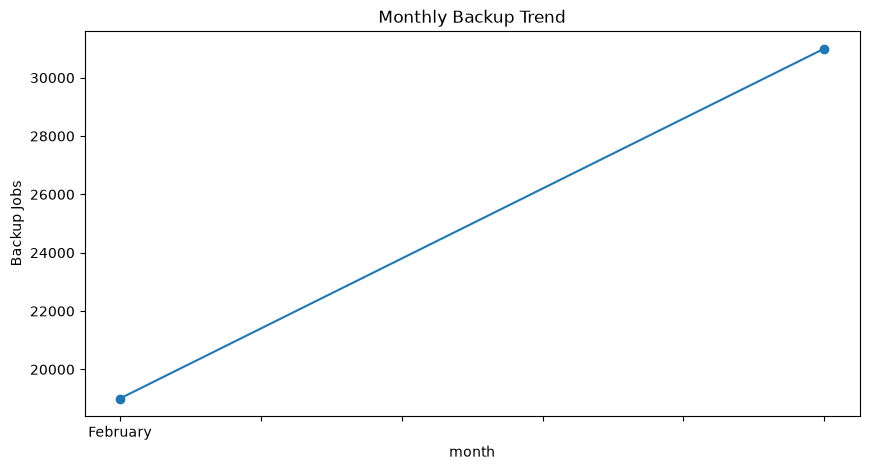

In [24]:
monthly_jobs.plot(
    kind="line",
    marker="o",
    figsize=(10,5)
)

plt.title("Monthly Backup Trend")

plt.ylabel("Backup Jobs")

plt.show()

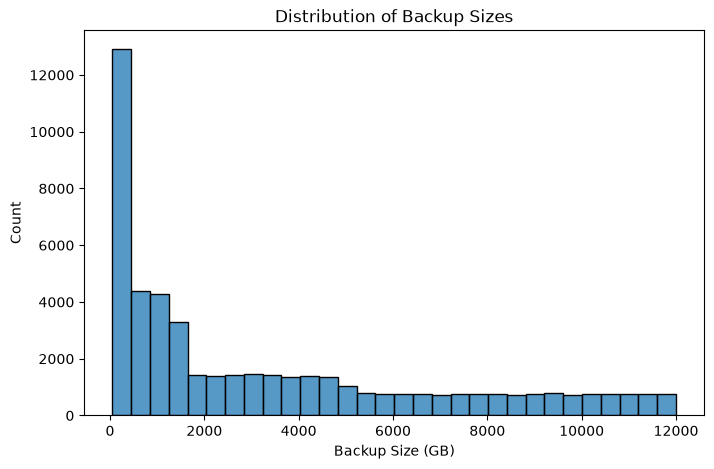

In [25]:
#Distribution of Backup Sizes
plt.figure(figsize=(8,5))

sns.histplot(
    backup_jobs_df["backup_size_gb"],
    bins=30
)

plt.title("Distribution of Backup Sizes")

plt.xlabel("Backup Size (GB)")

plt.show()

In [26]:
#Insight

#Most backups are concentrated in the lower and medium storage ranges, while a smaller number of enterprise backups contribute to the upper tail of the distribution.

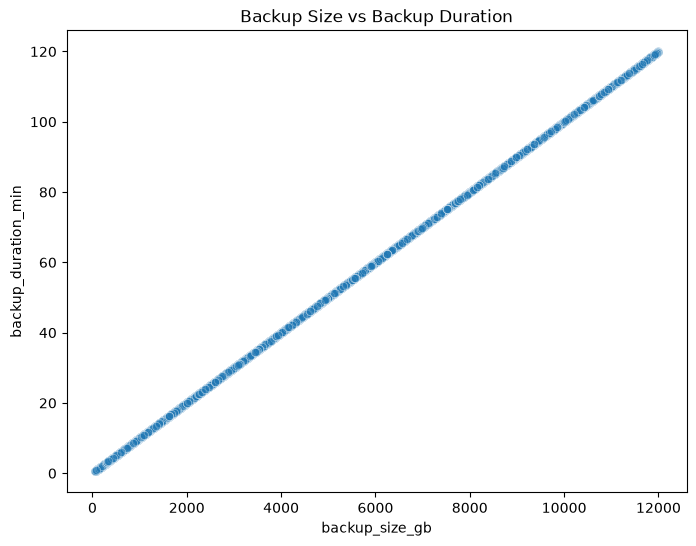

In [27]:
#Relationship Between Backup Size and Duration
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=backup_jobs_df,
    x="backup_size_gb",
    y="backup_duration_min",
    alpha=0.5
)

plt.title("Backup Size vs Backup Duration")

plt.show()

In [28]:
#Insight

#Larger backup sizes generally require longer execution times, indicating a positive relationship between data volume and backup duration.

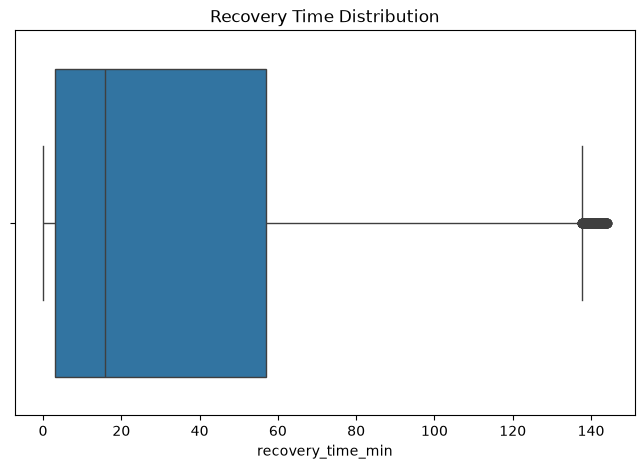

In [29]:
#Recovery Time Distribution
plt.figure(figsize=(8,5))

sns.boxplot(
    x=backup_jobs_df["recovery_time_min"]
)

plt.title("Recovery Time Distribution")

plt.show()

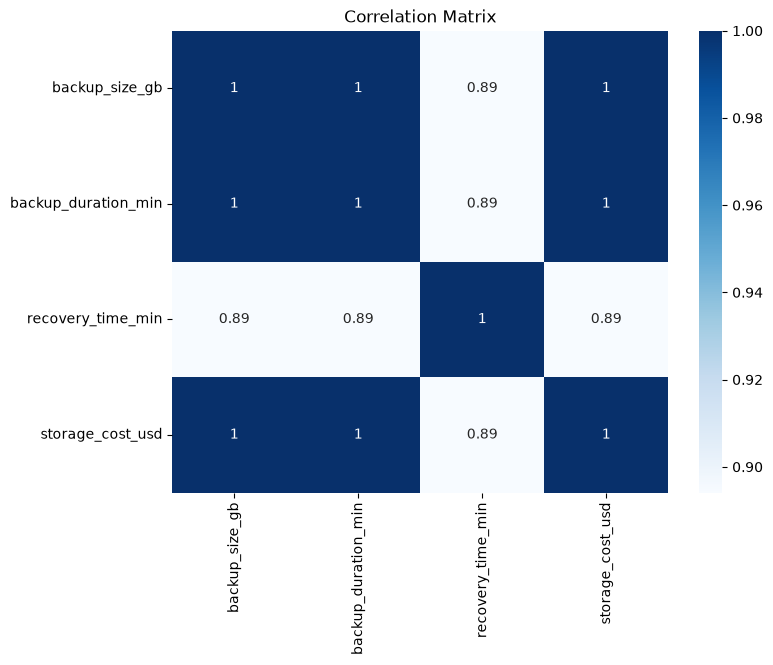

In [30]:
numeric_df = backup_jobs_df[
    [
        "backup_size_gb",
        "backup_duration_min",
        "recovery_time_min",
        "storage_cost_usd"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()